<a href="https://colab.research.google.com/github/pavan-8143516492/house-price-prediction-linear-regression/blob/main/house_price_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

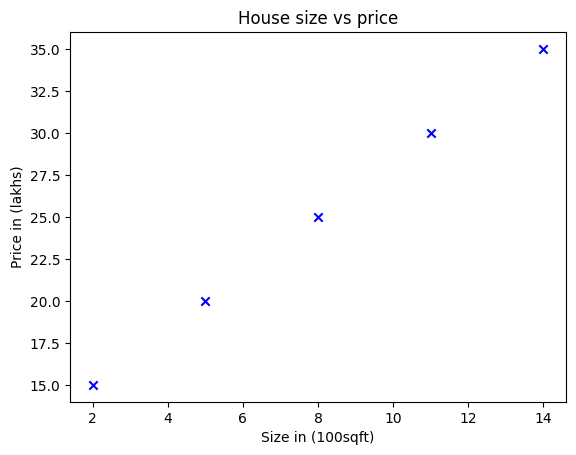

Iteration 0: Cost 23.771249999999984, w: 2.3000000000000003, b: 0.25
Iteration 100: Cost 9.1807454631323, w: 2.561306967332865, b: 2.5209195833511377
Iteration 200: Cost 5.940306557047415, w: 2.386304377551877, b: 4.309939621762433
Iteration 300: Cost 3.8436140216941745, w: 2.245534435693464, b: 5.749005449907412
Iteration 400: Cost 2.4869707658836777, w: 2.1323008169474758, b: 6.90657239341333
Iteration 500: Cost 1.609168755096237, w: 2.0412170795739955, b: 7.837705078583745
Iteration 600: Cost 1.0411960276734067, w: 1.9679504357468496, b: 8.586696817037131
Iteration 700: Cost 0.6736951389402581, w: 1.9090156439553925, b: 9.1891766066589
Iteration 800: Cost 0.43590748347927655, w: 1.861609218574467, b: 9.673803977385612
Iteration 900: Cost 0.28204943626599066, w: 1.8234760700711248, b: 10.063632304415345
Final parameters: w: 1.7930770951823396, b: 10.3743955639263


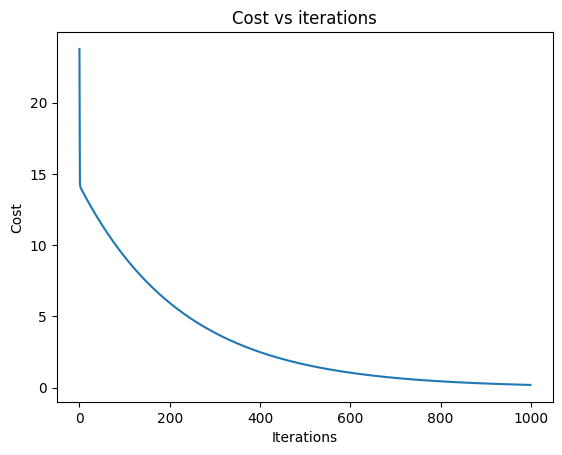

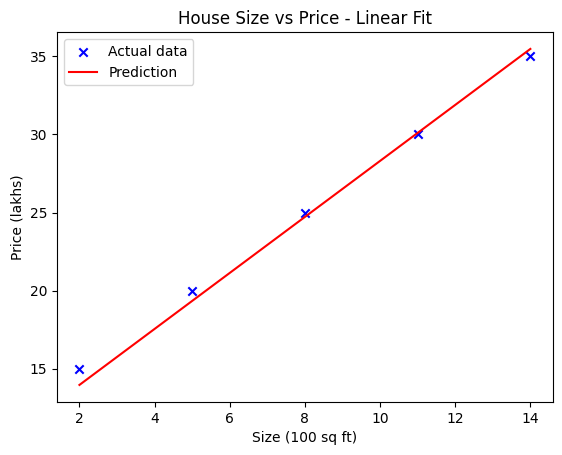

Predicted price for a house of size 1300 sq ft : 33.68439780129671 lakhs


In [7]:
# Step 1: Create a small dataset
# House size in units of 100 sq ft (e.g., 2 = 200 sq ft)
# Price in lakhs (Indian currency unit, 1 lakh = 100,000 INR)
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([2, 5, 8, 11, 14])     # size in 100 sq ft
y_train = np.array([15, 20, 25, 30, 35])  # price in lakhs

# Visualize the raw data to check if a linear relationship looks reasonable
plt.scatter(x_train, y_train, marker='x', c='b')
plt.title("House size vs price")
plt.xlabel("Size in (100sqft)")
plt.ylabel("Price in (lakhs)")
plt.show()


# Step 2: Define the cost function
def compute_cost(x, y, w, b):


    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i]) ** 2
    return cost / (2 * m)  # divide by 2m as per the standard cost function formula


# Step 3: Define the gradient computation
def compute_gradient(x, y, w, b):

    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])
    # Average the gradients across all training examples
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db


# Step 4: Implement gradient descent
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):


    w = w_in
    b = b_in
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        # Update parameters in the direction that REDUCES cost
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(x, y, w, b))

        # Print progress every 100 iterations to monitor convergence
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost_history[-1]}, w: {w}, b: {b}")

    return w, b, cost_history


# Step 5: Train the model
# Initialize parameters at 0 — gradient descent will learn the right values
w_init = 0
b_init = 0
alpha = 0.01       # learning rate: controls how big each update step is
num_iters = 1000   # number of times we update w and b

w_final, b_final, cost_history = gradient_descent(
    x_train, y_train, w_init, b_init, alpha, num_iters
)
print(f"Final parameters: w: {w_final}, b: {b_final}")


# Step 6: Visualize the cost over iterations
# A steadily decreasing curve confirms gradient descent is converging
plt.plot(cost_history)
plt.title("Cost vs iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


# Step 7: Visualize the fitted line against the data
plt.scatter(x_train, y_train, marker='x', c='b', label="Actual data")
plt.plot(x_train, w_final * x_train + b_final, c='red', label='Prediction')
plt.title("House Size vs Price - Linear Fit")
plt.xlabel("Size (100 sq ft)")
plt.ylabel("Price (lakhs)")
plt.legend()
plt.show()


# Step 8: Make a prediction for a new house size
size = 13  # represents 1300 sq ft
predicted_price = w_final * size + b_final
print(f"Predicted price for a house of size {size*100} sq ft : {predicted_price} lakhs")
